In [28]:
# lotka_volterra_experiment.py
"""Do a single numerical experiment from start to finish."""

import os
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import opinf

import utils
import config_lotka_volterra as config
import step1_generate_data as step1
import step1_5_estimate_priors as step1_5
import step2_fitgps as step2
import step3_estimate as step3
import step4_plot as step4
import plots as extra_plots
from scipy.interpolate import CubicSpline

def one_run(
    training_span: tuple[float, float],
    num_samples: int,
    noiselevel: float,
    num_regression_points: int,
    kernel:str,
    gp_regularizer: float = 1e-8,
    ndraws: int = 100,
    prior: bool = False,
    exportto: str = None,
    openonsave: bool = True,
    ensemble: bool = False,
    custom_save: str = "none",
    verbose: bool = False,
    plots: bool = False,
    no_seed: bool = False,
    interpolate: bool = True,
):
    r"""Do a single trial from start to finish (do not save intermediate data).

    Parameters
    ----------
    training_span : (float, float)
        Time domain over which to sample solution data.
    num_samples : int > 0
        Number of snapshots to sample.
    noiselevel : float >= 0
        Percentage of noise applied to the training snapshots.
    num_regression_points : int > 0
        Number of points at which to evaluate the GP state and derivative
        estimates.
    gp_regularizer : float >= 0
        Regularization hyperparameter for the GP inference in inverting for
        the least-squares weight matrix.
    ndraws : int
        Number of draws from the posterior distribution.
    exportto : str
        If given, write experiment data to an HDF5 files with ``exportto`` as
        the prefix.
    openonsave : bool
        If ``True`` (default), open figures as they are created.
    """
    if not no_seed: # If we don't pass in "no_seed" then we give a seed
        seed = 21092023
        print(f"Set seed: {seed}")
        np.random.seed(seed)
    else:
        print(f"No seed being used")

    print(kernel)
    if custom_save != "none":
        # Expand user (~) and construct full save path
        custom_save = os.path.expanduser(custom_save)
        save = f"{custom_save}/{num_samples}_{noiselevel}"

        # Create directory if it doesn't exist
        os.makedirs(save, exist_ok=True)
        print(f"Save directory ready at: {save}")
    else:
        save = config.figures_path()
    

    # Report on experimental scenario.
    utils.summarize_experiment(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        gp_regularizer=gp_regularizer,
        opinf_regularizer=None,
        ndraws=ndraws,
    )

    # Step 1: Generate data ---------------------------------------------------
    sampler = step1.TrajectorySampler(
        training_span=training_span,
        num_samples=num_samples,
        noiselevel=noiselevel,
        num_regression_points=num_regression_points,
        synced=False,
        integersonly=False,
        config=config
    )

    (
        truthmodel,
        time_domain_prediction,
        true_states,
        time_domains_sampled,
        snapshots_sampled,
    ) = sampler.sample()
    true_parameters = np.copy(truthmodel.parameters)

    # Step 1.5: Estimate period of data (Optional)
    period_length_priors = None
    if prior:
        period_length_priors = step1_5.estimate_period(
            t=time_domains_sampled,
            y=snapshots_sampled,
            plow=.5,
            phigh=20
        )
        if plots:
            extra_plots.period_length_prior(period_length_priors,time_domains_sampled,snapshots_sampled,save)

    # Step 2: Fit Gaussian processes to data ----------------------------------
    time_domain_training = np.linspace(
        training_span[0],
        training_span[-1],
        num_regression_points,
    )

In [29]:
from gpytorch.models import ExactGP
from gpytorch.kernels import ScaleKernel, CosineKernel, RQKernel, PeriodicKernel, ProductKernel
from gpytorch.means import ConstantMean
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.distributions import MultivariateNormal
import torch

torch.manual_seed(0)

class gp(ExactGP):
    def __init__(self, train_inputs, train_targets, likelihood, **kwargs):
        super().__init__(train_inputs, train_targets, likelihood)
        # self.covar = ScaleKernel(ProductKernel(CosineKernel(**kwargs),RQKernel(**kwargs)))
        self.covar = ScaleKernel(CosineKernel(**kwargs))
        self.likelihood = likelihood
        self.mean_module = ConstantMean()
    
    def forward(self, x):
        return MultivariateNormal(self.mean_module(x), self.covar(x))

Text(0.5, 1.0, 'Cosine Sample No Prior')

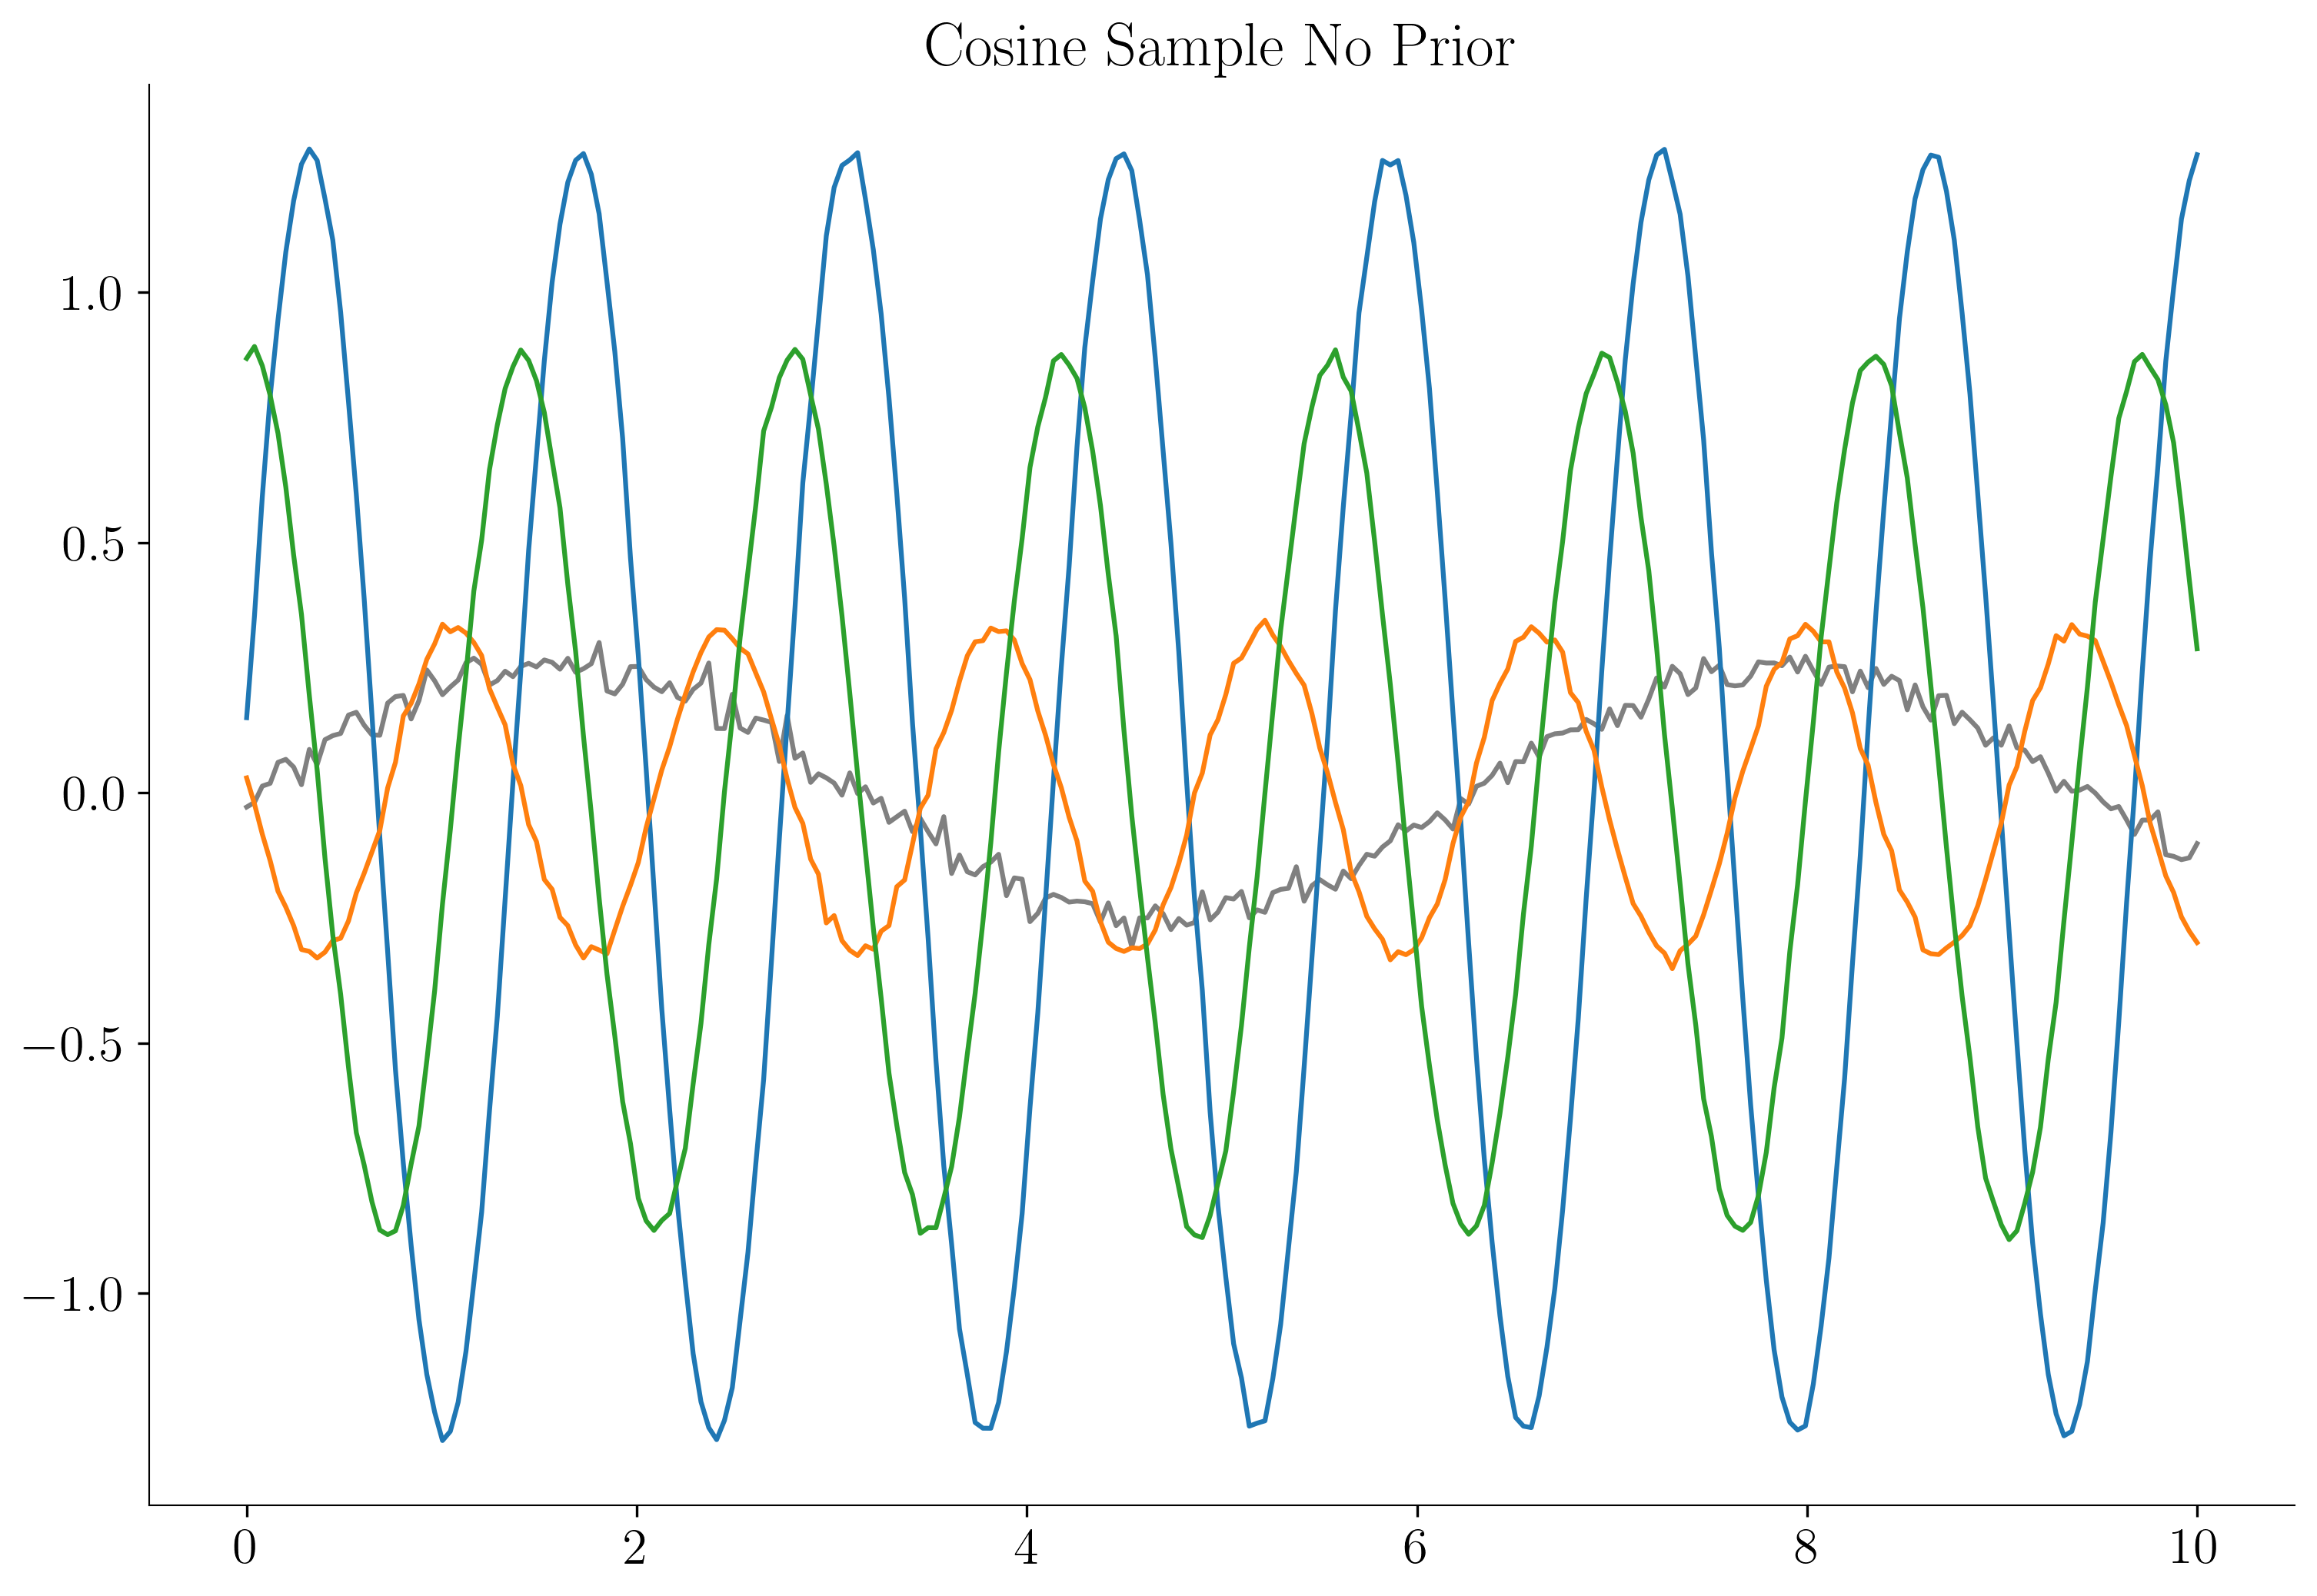

In [30]:
x = torch.linspace(0,10,250) 
y = (torch.sin(1*x) + torch.randn(x.shape)/10)/4
model = gp(train_inputs=x, train_targets=y, likelihood=GaussianLikelihood())
pred = model(x)
plt.plot(x,y, color='grey')
plt.plot(x, pred.sample().detach())
plt.plot(x, pred.sample().detach())
plt.plot(x, pred.sample().detach())
plt.title("Cosine Sample No Prior")

Estimated signal period to be 6.291751373493782 with stddev of 0.18671004703741287 for variable at index 0
gp(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (covar): ScaleKernel(
    (base_kernel): CosineKernel(
      (raw_period_length_constraint): Interval(2.959E+00, 3.333E+00)
    )
    (raw_outputscale_constraint): Positive()
  )
  (mean_module): ConstantMean()
)


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


Text(0.5, 1.0, 'Cosine Sample w/ Prior')

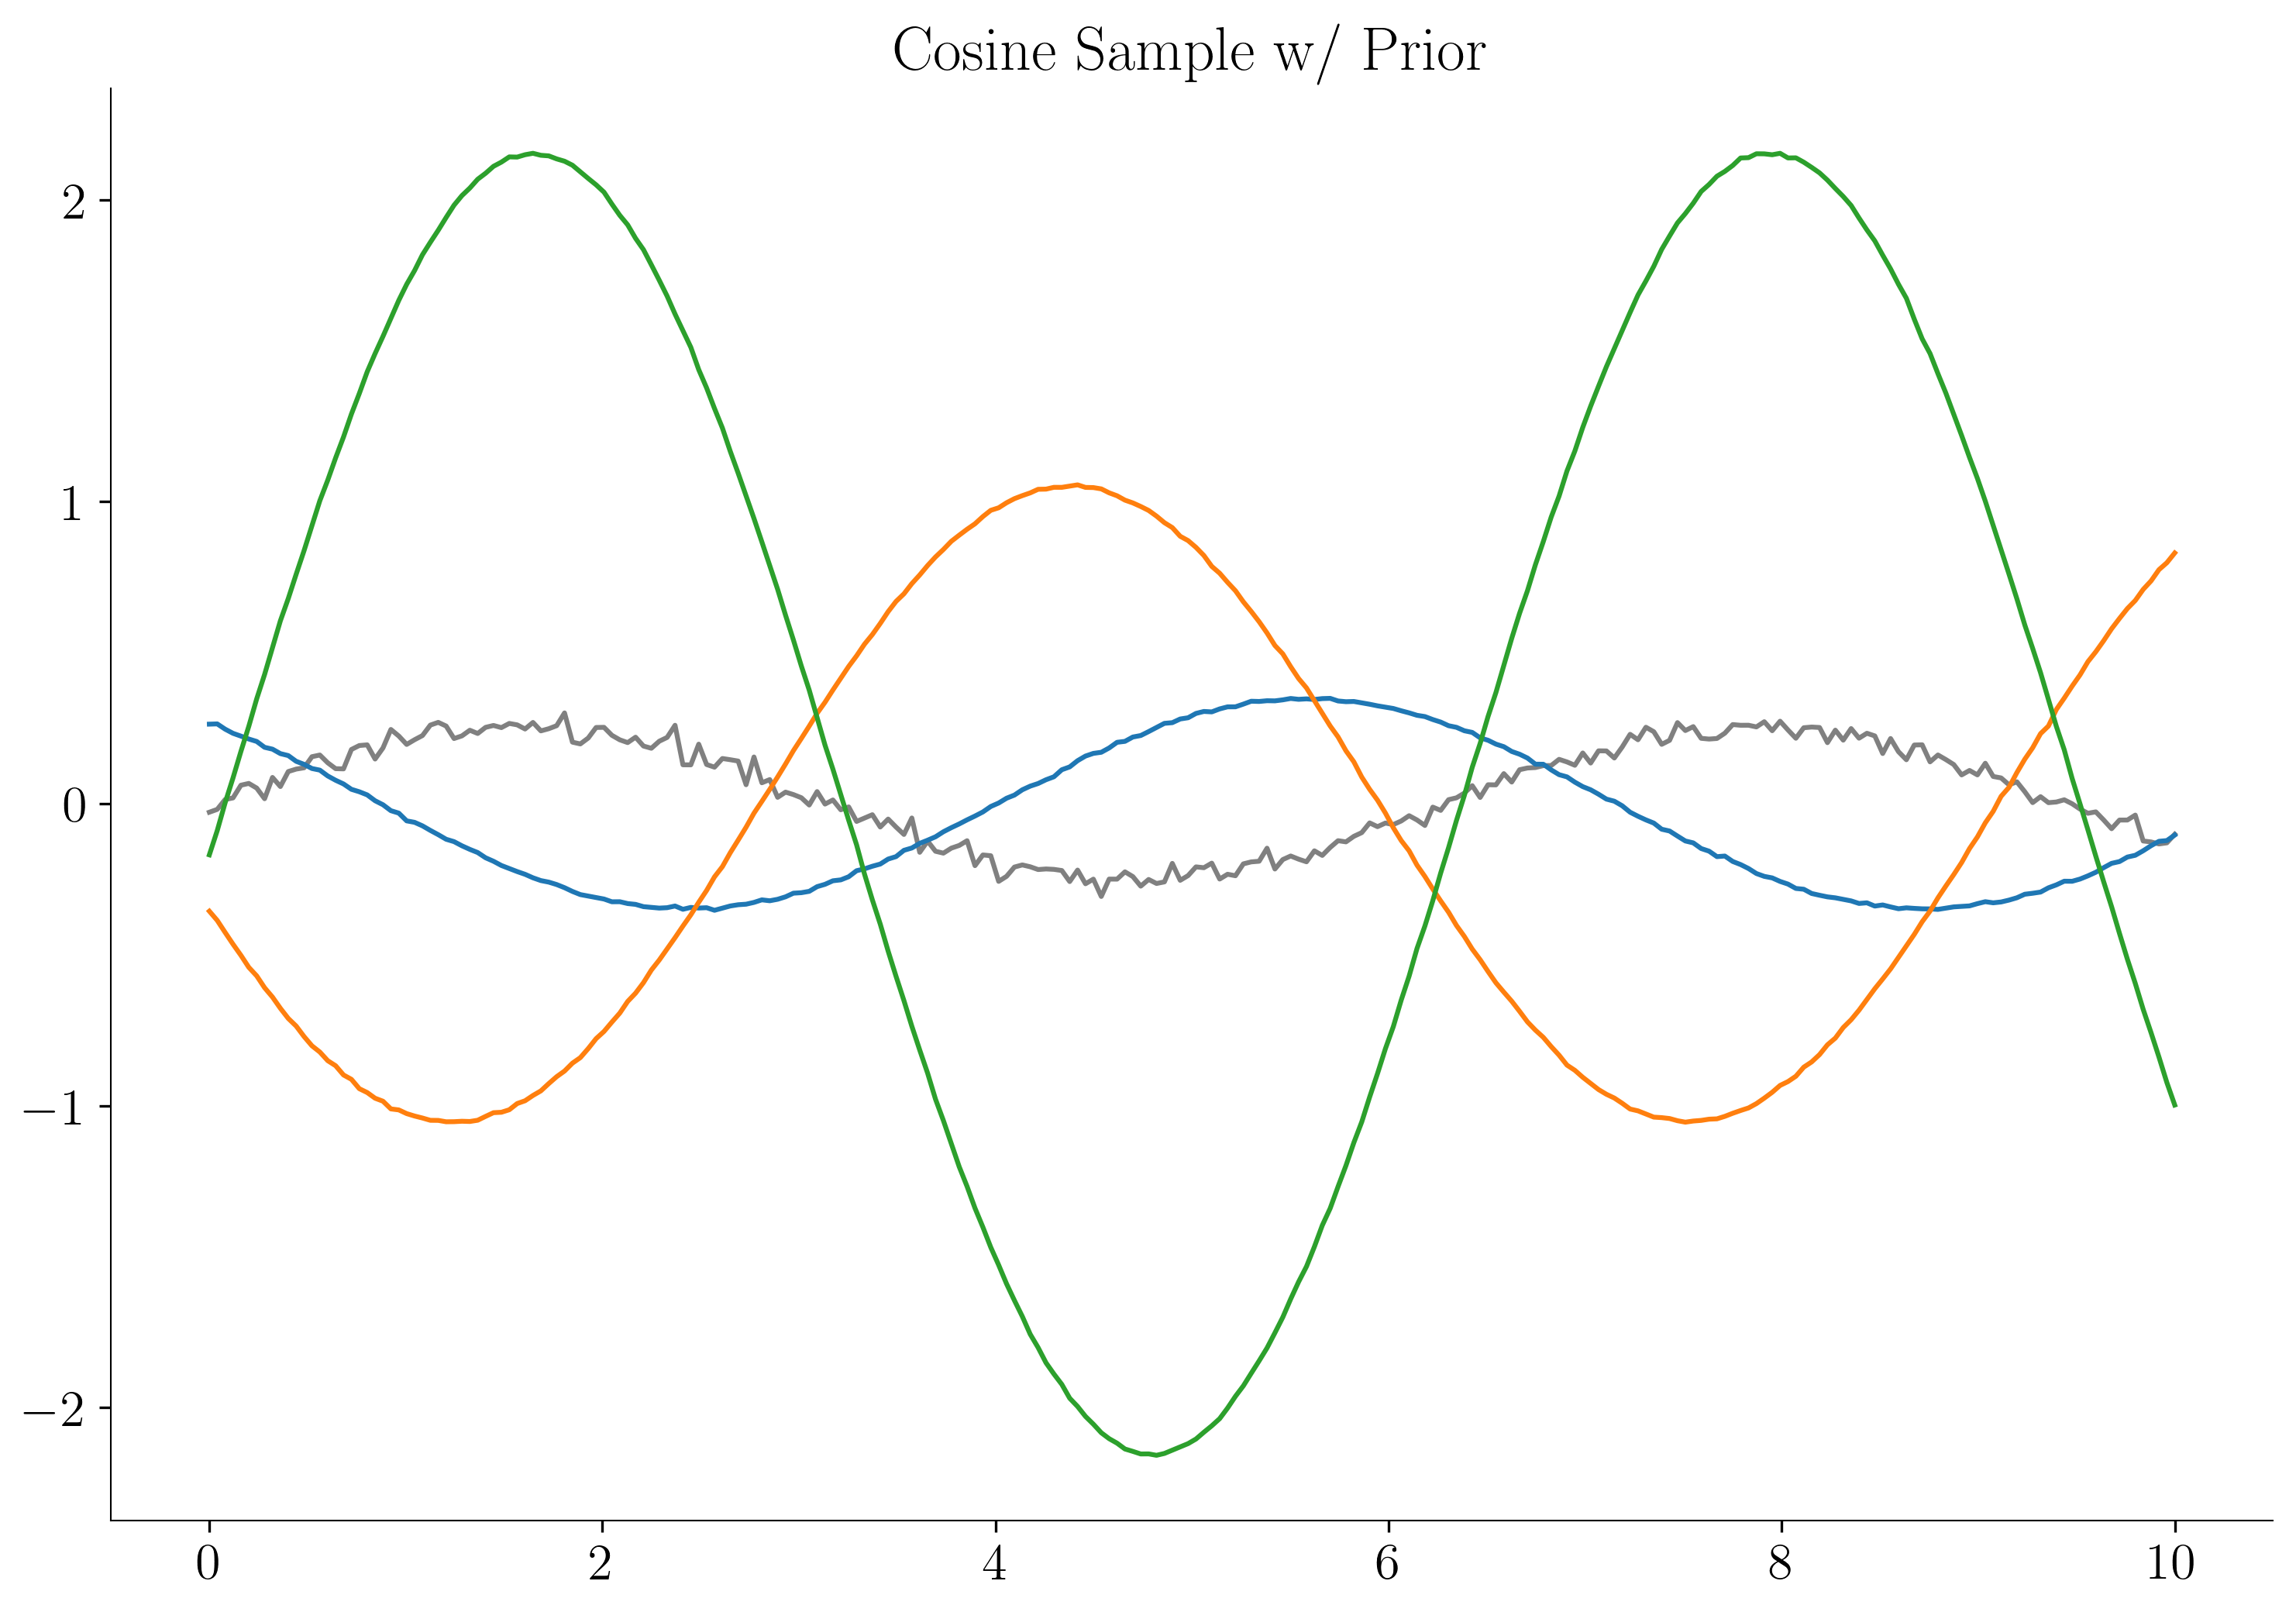

In [33]:
from gpytorch.priors import NormalPrior
from gpytorch.constraints import Interval
from step1_5_estimate_priors import estimate_period

period_prior = estimate_period([x.numpy()],[y.numpy()*4])[0]

# pmodel = gp(x,y,likelihood=GaussianLikelihood(), period_length_prior = NormalPrior(period_prior[0]/2,period_prior[1]))
pmodel = gp(x,y,likelihood=GaussianLikelihood(), period_length_constraint = Interval(period_prior[0] - period_prior[1], period_prior[0] + period_prior[1]))
# print(pmodel.covar.base_kernel[0][0].kernels[0].period_length_prior)
print(pmodel)
pred = pmodel(x)
plt.plot(x,y, color='grey')
plt.plot(x, pred.sample().detach())
plt.plot(x, pred.sample().detach())
plt.plot(x, pred.sample().detach())
plt.title("Cosine Sample w/ Prior")

Iteration 1/2 - Loss: 0.7773296236991882


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


Iteration 2/2 - Loss: 0.7430961728096008


/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-04 to the diagonal
  warnings.warn(
/Users/anthonypoole/miniconda3/envs/gpbayesopinf/lib/python3.12/site-packages/linear_operator/operators/_linear_operator.py:2163: NumericalWarning: Runtime Error when computing Cholesky decomposition: Matrix not positive definite after repeatedly adding jitter up to 1.0e-04.. Using symeig method.
  warnings.warn(


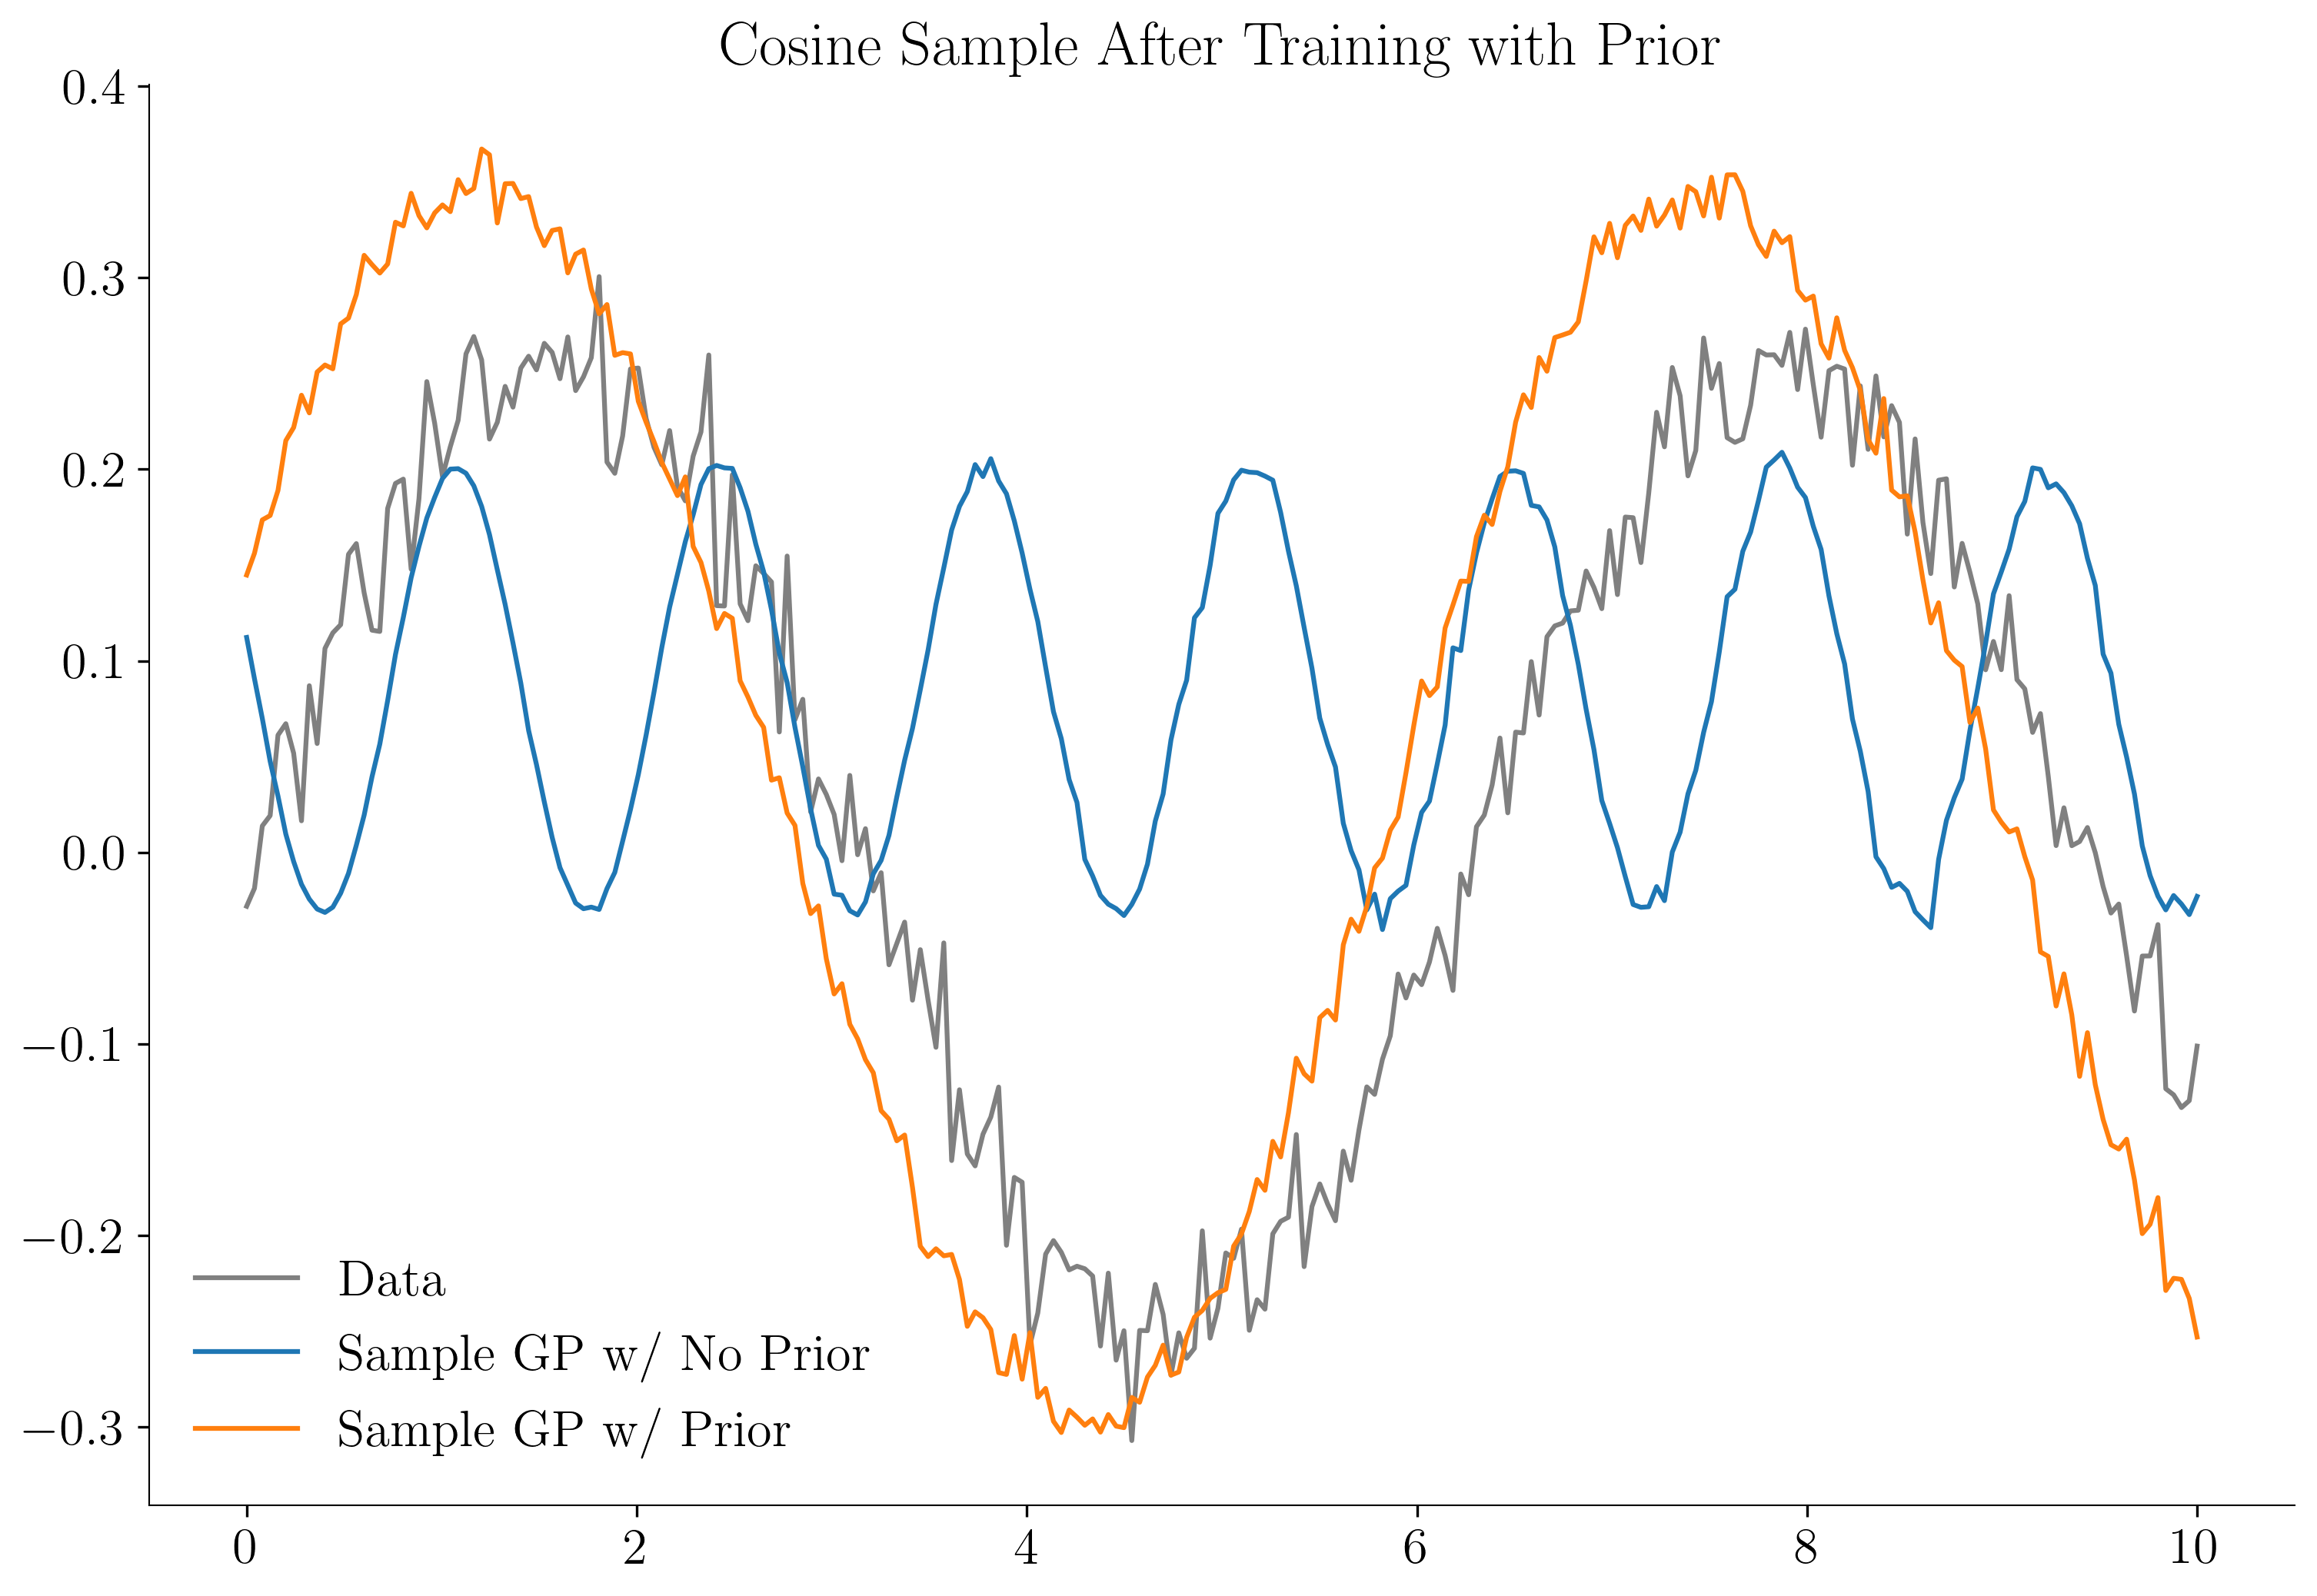

likelihood.noise_covar.raw_noise: Parameter containing:
tensor([-0.2000], requires_grad=True)
covar.raw_outputscale: Parameter containing:
tensor(-0.2000, requires_grad=True)
covar.base_kernel.raw_period_length: Parameter containing:
tensor([[-0.0275]], requires_grad=True)
mean_module.raw_constant: Parameter containing:
tensor(0.0849, requires_grad=True)


In [32]:
import torch.optim as optim
from gpytorch.mlls import ExactMarginalLogLikelihood

model.train()
pmodel.train()
model.likelihood.train()
pmodel.likelihood.train()
optimizer = optim.Adam(model.parameters(), lr=0.1)
poptimizer = optim.Adam(pmodel.parameters(), lr=0.1)

# Define the marginal log likelihood (which includes log priors)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
pmll = ExactMarginalLogLikelihood(pmodel.likelihood, pmodel)

training_iterations = 2
for i in range(training_iterations):
    optimizer.zero_grad()
    poptimizer.zero_grad()
    output = model(x)
    poutput = pmodel(x)
    loss = -mll(output, y)
    ploss = -mll(poutput, y)
    loss.backward()
    ploss.backward()
    optimizer.step()
    poptimizer.step()
    print(f'Iteration {i + 1}/{training_iterations} - Loss: {loss.item()}')

# Switch to eval mode and sample
model.eval()
pmodel.eval()
model.likelihood.eval()
pmodel.likelihood.eval()
pred = model(x)
ppred = pmodel(x)
plt.plot(x.numpy(), y.numpy(), color='grey', label='Data')
plt.plot(x.numpy(), pred.sample().detach().numpy(), label='Sample GP w/ No Prior')
plt.plot(x.numpy(), ppred.sample().detach().numpy(), label='Sample GP w/ Prior')
plt.title("Cosine Sample After Training with Prior")
plt.legend()
plt.show()

for name, param in model.named_hyperparameters():
    print(f"{name}: {param}")